In [1]:
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage
from langgraph.graph.message import add_messages
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langgraph.graph import END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.base import empty_checkpoint

/home/ridwanfatur/miniconda3/envs/py3_12_9/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
MAX_ITERATIONS = 5

class UserState(TypedDict):
    """
    State with messages for each session/user.
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]
    node_9_iteration_count: int

In [3]:
async def node_1(state: UserState, config: RunnableConfig):
    print("node_1")
    return {"messages": []}


async def node_2(state: UserState, config: RunnableConfig):
    print("node_2")
    return {"messages": []}


async def node_3(state: UserState, config: RunnableConfig):
    print("node_3", state["node_9_iteration_count"])
    return {"messages": []}


async def node_4(state: UserState, config: RunnableConfig):
    print("node_4")
    return {"messages": []}


async def node_5(state: UserState, config: RunnableConfig):
    print("node_5")
    return {"messages": []}


async def node_6(state: UserState, config: RunnableConfig):
    print("node_6")
    return {"messages": []}


async def node_7(state: UserState, config: RunnableConfig):
    print("node_7")
    return {"messages": []}


async def node_8(state: UserState, config: RunnableConfig):
    print("node_8")
    return {"messages": []}


async def node_9(state: UserState, config: RunnableConfig):
    current_iteration = state["node_9_iteration_count"]
    print("node_9", current_iteration)
    return {"messages": [], "node_9_iteration_count" : current_iteration + 1}


async def node_10(state: UserState, config: RunnableConfig):
    print("node_10", state["node_9_iteration_count"])
    return {"messages": []}

In [4]:
def node_2_conditional(state: UserState, config: RunnableConfig) -> Literal["node_3", "node_4"]:
    print("node_2_conditional")
    return "node_3"

def node_3_conditional(state: UserState, config: RunnableConfig) -> Literal["node_1", "node_4", "node_5"]:
    print("node_3_conditional")
    return "node_5"

def node_6_conditional(state: UserState, config: RunnableConfig) -> Literal["node_5", "node_7"]:
    print("node_6_conditional")
    return "node_7"    

def node_8_conditional(state: UserState, config: RunnableConfig) -> Literal["node_9", "node_10"]:
    print("node_8_conditional")
    current_iteration = state["node_9_iteration_count"]
    if current_iteration < MAX_ITERATIONS:
        return "node_9"
    return "node_10"

In [5]:
NODE_1 = "node_1"
NODE_2 = "node_2"
NODE_3 = "node_3"
NODE_4 = "node_4"
NODE_5 = "node_5"
NODE_6 = "node_6"
NODE_7 = "node_7"
NODE_8 = "node_8"
NODE_9 = "node_9"
NODE_10 = "node_10"

In [6]:
llm_graph = StateGraph(UserState)

# NODES
llm_graph.add_node(NODE_1, RunnableLambda(node_1))
llm_graph.add_node(NODE_2, RunnableLambda(node_2))
llm_graph.add_node(NODE_3, RunnableLambda(node_3))
llm_graph.add_node(NODE_4, RunnableLambda(node_4))
llm_graph.add_node(NODE_5, RunnableLambda(node_5))
llm_graph.add_node(NODE_6, RunnableLambda(node_6))
llm_graph.add_node(NODE_7, RunnableLambda(node_7))
llm_graph.add_node(NODE_8, RunnableLambda(node_8))
llm_graph.add_node(NODE_9, RunnableLambda(node_9))
llm_graph.add_node(NODE_10, RunnableLambda(node_10))

# EDGES
llm_graph.add_edge(NODE_1, NODE_2)
llm_graph.add_edge(NODE_4, NODE_6)
llm_graph.add_edge(NODE_5, NODE_6)
llm_graph.add_edge(NODE_7, NODE_8)
llm_graph.add_edge(NODE_9, NODE_8)
llm_graph.add_edge(NODE_10, END)

# CONDITIONAL EDGES
llm_graph.add_conditional_edges(NODE_2, node_2_conditional, {"node_3": NODE_3, "node_4": NODE_4})
llm_graph.add_conditional_edges(NODE_3, node_3_conditional, {"node_1": NODE_1, "node_4": NODE_4, "node_5": NODE_5})
llm_graph.add_conditional_edges(NODE_6, node_6_conditional, {"node_4": NODE_4, "node_7": NODE_7})
llm_graph.add_conditional_edges(NODE_8, node_8_conditional, {"node_9": NODE_9, "node_10": NODE_10})

# START
llm_graph.set_entry_point(NODE_1)

# COMPILE
checkpointer = MemorySaver()
langgraph_app = llm_graph.compile(
    checkpointer=checkpointer, 
    debug=False, 
    # interrupt_after=[NODE_3]
)

In [7]:
user_1_config = {
    "configurable": {
        "thread_id": "id-1",
        "checkpoint_ns": ""
    },
}

user_2_config = {
    "configurable": {
        "thread_id": "id-2",
        "checkpoint_ns": ""
    },
}

user_3_config = {
    "configurable": {
        "thread_id": "id-3",
        "checkpoint_ns": ""
    },
}

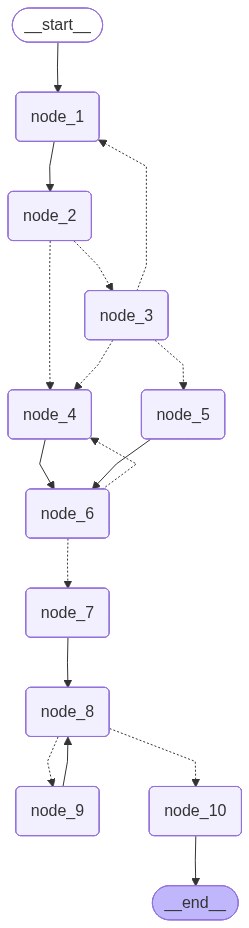

In [8]:
langgraph_app

In [ ]:
# Reset
checkpoint = empty_checkpoint()
checkpointer.put(
    config=config, 
    checkpoint=checkpoint, 
    metadata={"step": -1}, 
    new_versions={}
)

In [10]:
langgraph_app.get_state(user_1_config).values

{}